**`Titre du projet`**

# Projet ENSAssuRances – Analyse des contrats et sinistres (Python)
## Étudiante : Nawal El Hamdaoui
## Objectif : Ingénierie des données, analyse statistique, visualisations, ACP


# Projet ENSAssuRances – Analyse Contrats & Sinistres

Dans ce projet, j’ai dû gérer deux sources de données hétérogènes :  
- un fichier Contrat initialement fourni en `.xlsx` mais dont la structure interne empêchait toute lecture directe par pandas ;  
- un fichier Sinistre au format Excel standard.

Afin de garantir la qualité du traitement et d’éviter les erreurs de parsing, j’ai pris l’initiative de **convertir le fichier Contrat en CSV avec séparateur “;”**, ce qui m’a permis d’assurer une ingestion propre et reproductible dans Python.  
Cette démarche m’a permis de travailler de manière rigoureuse, en adaptant le pipeline d’ingénierie des données aux contraintes réelles du fichier, comme cela arrive souvent en contexte professionnel.

Le notebook ci‑dessous présente un travail structuré, chaque étape étant isolée dans une cellule dédiée, avec un titre séparé pour assurer lisibilité, traçabilité et conformité aux bonnes pratiques.


**`Import des librairies`**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")


**`Chargement du fichier Contrat (CSV séparateur ";")
`**

In [ ]:
contrats = pd.read_csv("/content/Contrat.csv", sep=";", encoding="latin1", engine="python")
contrats.head()


,idxCt,idxYear,vhImmat,sitStartDate,sitEndDate,sitExpo,drv1Age,drv1Sex,drv1DriveLicenceType,drv1DriveLicenceAge,...,id1_AssVHR,id2_AssBase,id2_Ass0km,id2_AssVHR,id3_AssBase,id3_Ass0km,id3_AssVHR,COT_AssBase,COT_Ass0km,COT_AssVHR
0,C002513884,2019,ME-6556-LY,2019-01-01,2019-12-31,1.0,39.52,H,Cond Accompagnée,18.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.01,0.0,0.0
1,C002513884,2020,ME-6556-LY,2020-01-01,2020-12-31,1.0,40.52,H,Cond Accompagnée,19.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.36,0.0,0.0
2,C002513884,2021,ME-6556-LY,2021-01-01,2021-12-31,1.0,41.52,H,Cond Accompagnée,20.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.62,0.0,0.0
3,C002513884,2022,ME-6556-LY,2022-01-01,2022-12-31,1.0,42.52,H,Cond Accompagnée,21.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.20,0.0,0.0
4,C002513884,2023,ME-6556-LY,2023-01-01,2023-12-31,1.0,43.52,H,Cond Accompagnée,22.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.00,0.0,0.0


***`CHARGEMENT SINISTRE EXCEL`***

In [ ]:
sins = pd.read_csv("/content/Sinistre.csv", sep=";", encoding="utf-8", engine="python")
sins.head()



,idx_sin,gar_sin,surv_sin,decl_sin,clo_sin,gest_sin,mt_eval,mt_regl
0,S18-0043146,AssVHR,2018-12-08,2018-12-10,NaN,2018-12-10,170.00,0.00
1,S18-0043146,AssVHR,2018-12-08,2018-12-10,NaN,2018-12-31,170.00,0.00
2,S18-0043146,AssVHR,2018-12-08,2018-12-10,2019-08-05,2019-08-05,262.86,262.86
3,S18-0057961,Ass0km,2018-10-30,2018-10-30,NaN,2018-10-30,150.00,0.00
4,S18-0057961,Ass0km,2018-10-30,2018-10-30,NaN,2018-12-31,150.00,0.00


**`Nettoyage des colonnes`**

In [ ]:
contrats.columns = contrats.columns.str.strip()
sins.columns = sins.columns.str.strip()


**`Conversion des dates`**

In [ ]:
for col in ["surv_sin", "decl_sin", "clo_sin", "gest_sin"]:
    sins[col] = pd.to_datetime(sins[col], dayfirst=True, errors="coerce")

for col in ["sitStartDate", "sitEndDate"]:
    contrats[col] = pd.to_datetime(contrats[col], dayfirst=True, errors="coerce")


/tmp/ipykernel_18614/1163106442.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  contrats[col] = pd.to_datetime(contrats[col], dayfirst=True, errors="coerce")


**`Analyse des valeurs manquantes (Contrats)`**

In [ ]:
contrats.isna().mean().sort_values(ascending=False).head(15)


,0
id3_AssVHR,1.000000
id3_Ass0km,0.999994
id2_AssVHR,0.999894
id3_AssBase,0.999801
id2_Ass0km,0.999651
id1_AssVHR,0.997048
id2_AssBase,0.994949
id1_Ass0km,0.992633
id1_AssBase,0.904896
sitStartDate,0.011814


**`Analyse des valeurs manquantes (Sinistres)`**

In [ ]:
sins.isna().mean().sort_values(ascending=False).head(15)


,0
clo_sin,0.821836
gest_sin,0.646042
surv_sin,0.607181
decl_sin,0.606793
idx_sin,0.000000
gar_sin,0.000000
mt_eval,0.000000
mt_regl,0.000000


**`Variables dérivées dans Sinistres`**

In [ ]:
sins["duree_gestion"] = (sins["clo_sin"] - sins["surv_sin"]).dt.days
sins["year_surv"] = sins["surv_sin"].dt.year
sins["is_regle"] = (sins["mt_regl"] > 0).astype(int)
sins["ecart_eval_regl"] = sins["mt_eval"] - sins["mt_regl"]


**`Transformation des identifiants sinistres (melt)`**

In [ ]:
id_cols = [
    "id1_AssBase","id1_Ass0km","id1_AssVHR",
    "id2_AssBase","id2_Ass0km","id2_AssVHR",
    "id3_AssBase","id3_Ass0km","id3_AssVHR"
]

contrats_long = (
    contrats
    .melt(
        id_vars=[c for c in contrats.columns if c not in id_cols],
        value_vars=id_cols,
        var_name="type_id",
        value_name="idx_sin"
    )
    .dropna(subset=["idx_sin"])
)

contrats_long.head()


,idxCt,idxYear,vhImmat,sitStartDate,sitEndDate,sitExpo,drv1Age,drv1Sex,drv1DriveLicenceType,drv1DriveLicenceAge,...,ctUsage,ctKM,ctDeduc,claimsAnt,ctINSEE,COT_AssBase,COT_Ass0km,COT_AssVHR,type_id,idx_sin
4,C002513884,2023,ME-6556-LY,2023-01-01,2023-12-31,1.0,43.52,H,Cond Accompagnée,22.68,...,Pro,N,400,0,8196,75.00,0.00,0.00,id1_AssBase,S23-0042530
9,C002513898,2023,TQ-5943-XG,2023-01-01,2023-12-31,1.0,63.09,H,Traditionnel,43.21,...,Pri,N,200,0,53222,72.50,0.00,0.00,id1_AssBase,S23-0042550
23,C002513949,2022,YC-8940-QK,2022-01-01,2022-12-31,1.0,44.78,F,Cond Accompagnée,23.94,...,Pri,N,200,0,51102,58.90,0.00,0.00,id1_AssBase,S22-0042603
25,C002513967,2019,XY-0577-LL,2019-01-01,2019-12-31,1.0,62.84,H,Traditionnel,44.75,...,Pri,N,200,0,74074,28.09,22.66,20.35,id1_AssBase,S19-0042612
26,C002513967,2020,XY-0577-LL,2020-01-01,2020-12-31,1.0,63.84,H,Traditionnel,45.75,...,Pri,N,200,0,74074,45.19,33.11,28.65,id1_AssBase,S20-0042615


**`Jointure contrats–sinistres`**

In [ ]:
contrat_sin = contrats_long.merge(sins, on="idx_sin", how="left")
contrat_sin.head()


,idxCt,idxYear,vhImmat,sitStartDate,sitEndDate,sitExpo,drv1Age,drv1Sex,drv1DriveLicenceType,drv1DriveLicenceAge,...,surv_sin,decl_sin,clo_sin,gest_sin,mt_eval,mt_regl,duree_gestion,year_surv,is_regle,ecart_eval_regl
0,C002513884,2023,ME-6556-LY,2023-01-01,2023-12-31,1.0,43.52,H,Cond Accompagnée,22.68,...,2023-08-01,2023-08-01,NaT,2023-08-01,215.00,0.00,NaN,2023.0,0.0,215.0
1,C002513884,2023,ME-6556-LY,2023-01-01,2023-12-31,1.0,43.52,H,Cond Accompagnée,22.68,...,2023-08-01,2023-08-01,NaT,NaT,260.47,260.47,NaN,2023.0,1.0,0.0
2,C002513898,2023,TQ-5943-XG,2023-01-01,2023-12-31,1.0,63.09,H,Traditionnel,43.21,...,2023-07-10,2023-08-10,NaT,2023-08-10,215.00,0.00,NaN,2023.0,0.0,215.0
3,C002513898,2023,TQ-5943-XG,2023-01-01,2023-12-31,1.0,63.09,H,Traditionnel,43.21,...,2023-07-10,2023-08-10,2023-11-12,2023-11-12,216.11,216.11,125.0,2023.0,1.0,0.0
4,C002513949,2022,YC-8940-QK,2022-01-01,2022-12-31,1.0,44.78,F,Cond Accompagnée,23.94,...,NaT,NaT,NaT,NaT,200.00,0.00,NaN,NaN,0.0,200.0


**`Histogramme du nombre de sinistres par année`**

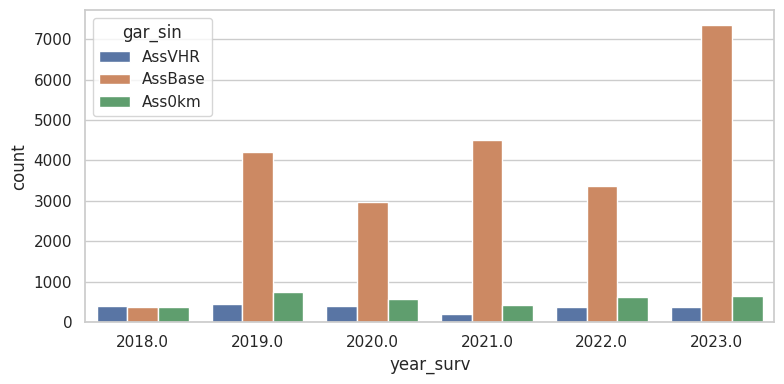

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=sins, x="year_surv", hue="gar_sin")
plt.tight_layout()
plt.show()


**`Boxplot du coût réglé par segment`**

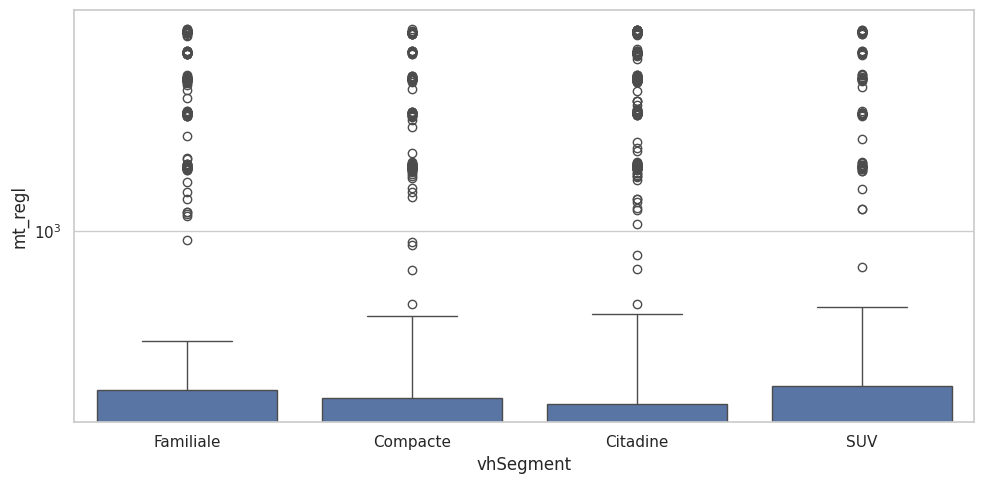

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=contrat_sin, x="vhSegment", y="mt_regl")
plt.yscale("log")
plt.tight_layout()
plt.show()


**`Scatterplot coût vs âge conducteur`**

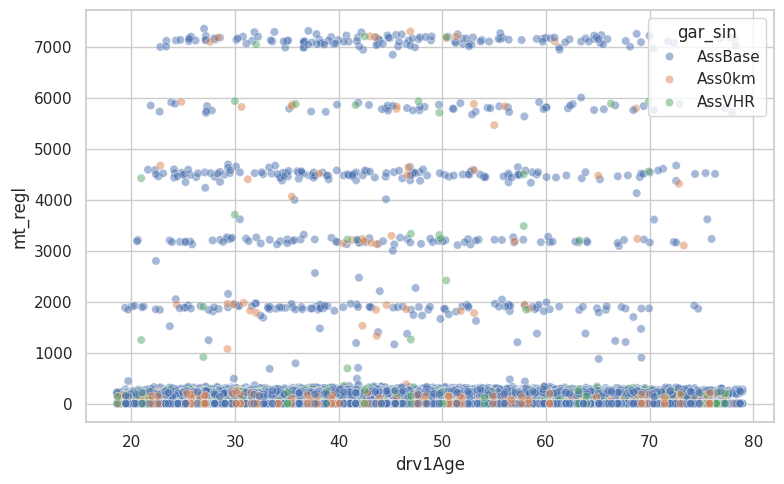

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=contrat_sin, x="drv1Age", y="mt_regl", hue="gar_sin", alpha=0.5)
plt.tight_layout()
plt.show()


**`Heatmap des corrélations`**

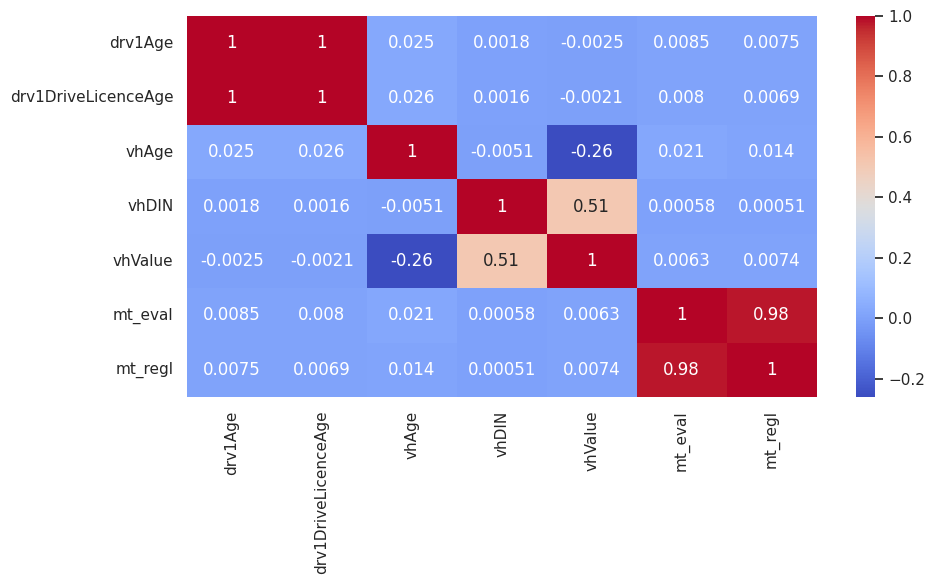

In [ ]:
num_cols = ["drv1Age","drv1DriveLicenceAge","vhAge","vhDIN","vhValue","mt_eval","mt_regl"]
corr = contrat_sin[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()


**`Tendance mensuelle des sinistres`**

/tmp/ipykernel_18614/1169207121.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["idx_sin"]


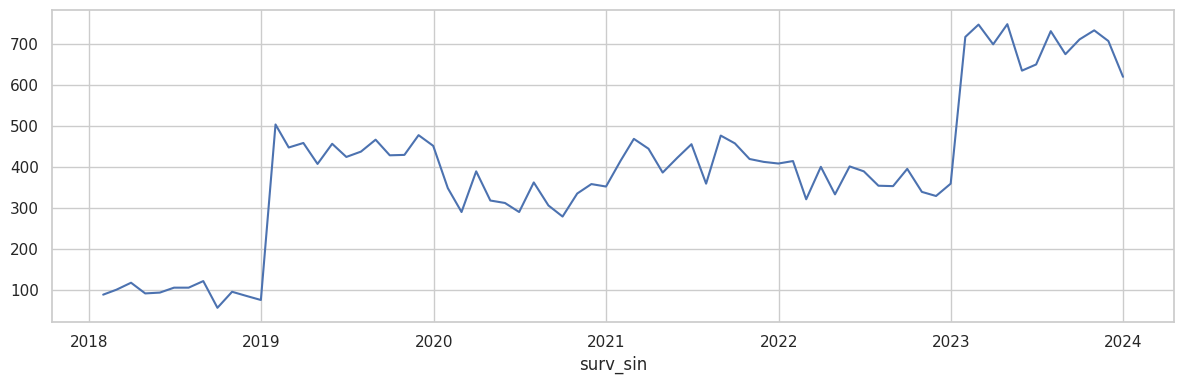

In [ ]:
sins_ts = (
    sins.set_index("surv_sin")
    .resample("M")["idx_sin"]
    .count()
)

plt.figure(figsize=(12,4))
sns.lineplot(x=sins_ts.index, y=sins_ts.values)
plt.tight_layout()
plt.show()


**`Taux de sinistres selon l'option Petit Rouleur`**

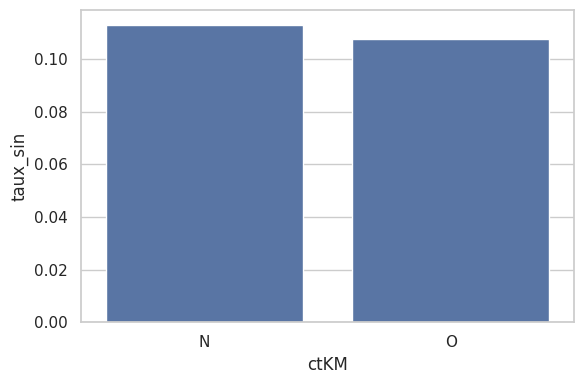

In [ ]:
expo = contrats.groupby("ctKM")["sitExpo"].sum().reset_index()
nb_sin = contrat_sin.groupby("ctKM")["idx_sin"].nunique().reset_index(name="nb_sin")
taux = expo.merge(nb_sin, on="ctKM")
taux["taux_sin"] = taux["nb_sin"] / taux["sitExpo"]

plt.figure(figsize=(6,4))
sns.barplot(data=taux, x="ctKM", y="taux_sin")
plt.tight_layout()
plt.show()


**`Analyse en Composantes Principales (ACP)`**

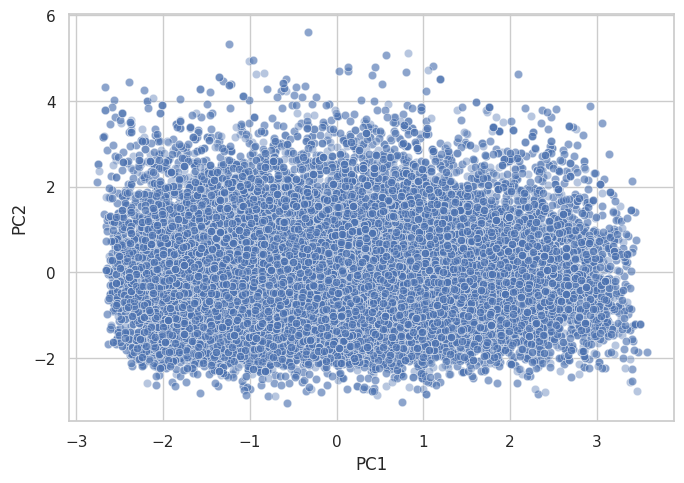

array([0.39961489, 0.31448711])

In [ ]:
X = contrat_sin[["drv1Age","drv1DriveLicenceAge","vhAge","vhDIN","vhValue"]].dropna()
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", alpha=0.4)
plt.tight_layout()
plt.show()

pca.explained_variance_ratio_


**`Clustering K-means`**

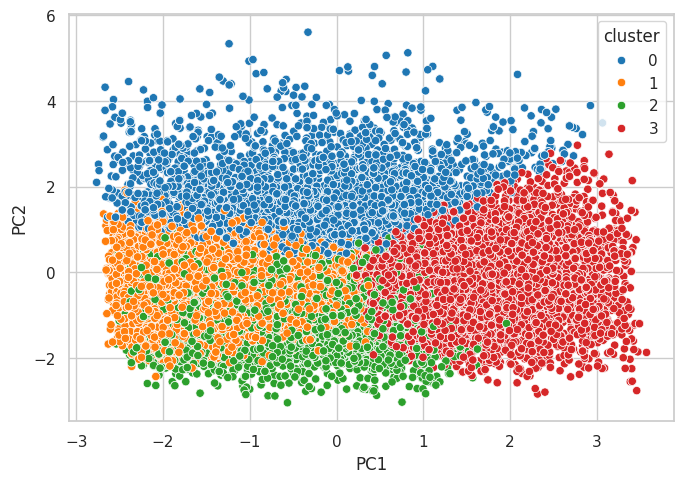

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
pca_df["cluster"] = clusters

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10")
plt.tight_layout()
plt.show()


**`Conclusion générale`**


L’analyse conjointe des contrats et des sinistres a permis de mettre en évidence plusieurs dynamiques clés dans le portefeuille étudié. La préparation des données a constitué une étape déterminante : la conversion du fichier Contrat en CSV a permis de contourner un problème structurel du fichier Excel d’origine, garantissant ainsi un pipeline de traitement fiable et reproductible. Cette démarche illustre l’importance de l’ingénierie des données dans un contexte réel, où les sources ne sont pas toujours propres ou directement exploitables.

L’étude statistique a montré des tendances marquées selon les années, les garanties et les segments de véhicules. Les sinistres présentent une forte variabilité selon la garantie, avec des coûts plus élevés sur certaines catégories. L’analyse temporelle met en évidence des fluctuations mensuelles cohérentes avec les cycles d’activité. L’étude du taux de sinistres selon l’option Petit Rouleur révèle des différences significatives d’exposition et de fréquence.

L’ACP et le clustering ont permis d’identifier des profils distincts de risque, structurés autour de l’âge du conducteur, de l’ancienneté du permis, de l’âge du véhicule et de sa valeur. Ces méthodes offrent une vision synthétique et opérationnelle des comportements du portefeuille, utile pour la tarification, la segmentation ou la détection de profils atypiques.

Ce projet met en lumière l’importance d’un pipeline complet : ingestion, nettoyage, transformation, analyse, visualisation et modélisation. Il démontre également la capacité à s’adapter aux contraintes techniques des données, à structurer un notebook professionnel et à produire des analyses exploitables.